# 03 — Modélisation Ressources (Modèle A)
## Jour 2, sous-étape 2c — Baseline

Cible : `Quantite_Restante` (grain Localité × Tâche × Matériel, 997 lignes). Conformément à la méthodologie du guide Régression/Classification/Clustering : **toujours un baseline simple avant un modèle complexe** — ici une régression linéaire régularisée (Ridge), qui sera comparée au Jour 3 à un Gradient Boosting Regressor.

*Le modèle retenu et la comparaison aux baselines seront ajoutés au Jour 3, dans ce même notebook.*

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

pd.set_option('display.max_columns', None)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/processed/table_pivot_anonymisee.csv')
df.shape

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import csr_matrix, issparse


(997, 23)

## 1. Choix des variables explicatives

Aucune variable de contexte locale (population, distance au poste source, dispersion de l'habitat) n'est disponible dans les données ElecTrack Pro actuelles — contrairement à l'exemple théorique du guide de référence. Le baseline s'appuie donc sur ce qui est réellement disponible : la planification (`Qte_Prevue`, `Poids` de la tâche) et le contexte administratif/opérationnel (`Departement`, `Commune`, `Categorie`, `ID_Tache`, `Statut`).

**Choix explicite, pour éviter toute fuite de données :** `Avancement_Global_Localite_pct` n'est *pas* utilisé comme variable — cette colonne agrège `Qte_Realisee` sur toutes les tâches de la localité, dont celle qu'on cherche justement à prédire. Ce n'est pas une fuite au sens strict (l'information serait connue au moment réel de la prédiction), mais on l'exclut par prudence méthodologique, conformément au réflexe du guide (piège n°1) : *« pour chaque variable, se demander : est-ce que je connaîtrais cette valeur au moment où je dois réellement faire la prédiction ? »*.

In [4]:
cat_features = ['Departement', 'Commune', 'Categorie', 'ID_Tache', 'Statut']
num_features = ['Poids', 'Qte_Prevue', 'Nb_Anomalies_Signalees']

def build_pipe(model):
    prep = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features),
    ])
    return Pipeline([('prep', prep), ('model', model)])

## 2. Premier essai — modèle unique, mélangeant les unités

Rappel de l'EDA (2a) : les quantités mélangent des unités comptées (« U ») et des mètres de câble (« m »). Vérifions ce que cela produit si on l'ignore.

In [5]:
X = df[cat_features + num_features]
y = df['Quantite_Restante']
cv = KFold(n_splits=5, shuffle=True, random_state=42)

pred_ridge_global = cross_val_predict(build_pipe(Ridge(alpha=1.0, random_state=42)), X, y, cv=cv)
pred_dummy_global = cross_val_predict(build_pipe(DummyRegressor(strategy='mean')), X, y, cv=cv)

def afficher_metriques(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:25s} MAE={mae:9.2f}  RMSE={rmse:9.2f}  R²={r2:6.3f}")

print("=== Modèle unique (global, mélange d'unités) ===")
afficher_metriques(y, pred_dummy_global, "Baseline naïve (moyenne)")
afficher_metriques(y, pred_ridge_global, "Ridge (régularisée)")

print()
print("Mais évalué séparément par unité, ce modèle unique s'effondre sur le sous-groupe 'U' :")
for unite in ['U', 'm']:
    mask = df['Unite'] == unite
    afficher_metriques(y[mask], pred_ridge_global[mask], f"  Ridge (global) sur {unite!r}")

=== Modèle unique (global, mélange d'unités) ===
Baseline naïve (moyenne)  MAE=   724.23  RMSE=  2008.42  R²=-0.000
Ridge (régularisée)       MAE=   318.49  RMSE=   962.14  R²= 0.770

Mais évalué séparément par unité, ce modèle unique s'effondre sur le sous-groupe 'U' :
  Ridge (global) sur 'U'  MAE=   129.20  RMSE=   150.36  R²=-15.701
  Ridge (global) sur 'm'  MAE=  1252.54  RMSE=  2319.94  R²= 0.717


**Constat :** en apparence, le modèle global semble bon (R² = 0,77) — mais ce chiffre est trompeur : il est dominé par le sous-groupe « m » (valeurs en milliers, qui écrasent l'erreur globale). Évalué séparément sur le sous-groupe « U » (unités comptées, valeurs typiquement entre 0 et 20), ce même modèle devient **catastrophique** (R² très négatif) : le `DummyRegressor` prédit la moyenne *globale* (mélangeant mètres et unités), une valeur totalement hors d'échelle pour les petites quantités comptées.

C'est la confirmation, au niveau modélisation cette fois, du piège déjà repéré en EDA (2a) : mélanger des unités incompatibles ne se contente pas de fausser des statistiques descriptives — ça casse un modèle entraîné dessus. **Correction : entraîner deux modèles séparés, stratifiés par unité**, plutôt qu'un seul modèle évalué après coup par sous-groupe.

## 3. Modèles stratifiés par unité — approche retenue

In [6]:
resultats = {}

for unite, label_unite in [('U', 'unités comptées'), ('m', 'mètres de câble')]:
    sub = df[df['Unite'] == unite].reset_index(drop=True)
    X_sub = sub[cat_features + num_features]
    y_sub = sub['Quantite_Restante']
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    pred_ridge = cross_val_predict(build_pipe(Ridge(alpha=1.0, random_state=42)), X_sub, y_sub, cv=cv)
    pred_dummy = cross_val_predict(build_pipe(DummyRegressor(strategy='mean')), X_sub, y_sub, cv=cv)

    print(f"\n=== Unité = {unite!r} ({label_unite}, {len(sub)} lignes) ===")
    afficher_metriques(y_sub, pred_dummy, "Baseline naïve (moyenne)")
    afficher_metriques(y_sub, pred_ridge, "Ridge (régularisée)")

    resultats[unite] = {'y': y_sub, 'pred': pred_ridge, 'label': label_unite}


=== Unité = 'U' (unités comptées, 829 lignes) ===
Baseline naïve (moyenne)  MAE=    19.89  RMSE=    36.86  R²=-0.004
Ridge (régularisée)       MAE=    13.19  RMSE=    26.51  R²= 0.481

=== Unité = 'm' (mètres de câble, 168 lignes) ===
Baseline naïve (moyenne)  MAE=  2637.24  RMSE=  4378.94  R²=-0.009
Ridge (régularisée)       MAE=  1333.31  RMSE=  2316.62  R²= 0.718



=== Unité = 'm' (mètres de câble, 168 lignes) ===
Baseline naïve (moyenne)  MAE=  2637.24  RMSE=  4378.94  R²=-0.009
Ridge (régularisée)       MAE=  1375.71  RMSE=  2350.69  R²= 0.709


**Constat :** dans leur propre unité, les deux modèles Ridge apportent un gain net et interprétable par rapport au baseline naïf :

- **Mètres de câble** : MAE ≈ 1 376 m (vs 2 637 m naïf), R² = 0,71 — le modèle explique une bonne part de la variance.
- **Unités comptées** : MAE ≈ 13 unités (vs 20 naïf), R² = 0,47 — gain plus modeste, cohérent avec des quantités plus petites et plus dispersées (poteaux, IACM, transformateurs, chacun avec sa propre logique de dimensionnement).

Ces deux chiffres sont directement communicables à un chargé de projet : *« en moyenne, le modèle se trompe de 1 376 m de câble ou de 13 unités de matériel par ligne de commande »*.

## 4. Analyse des résidus

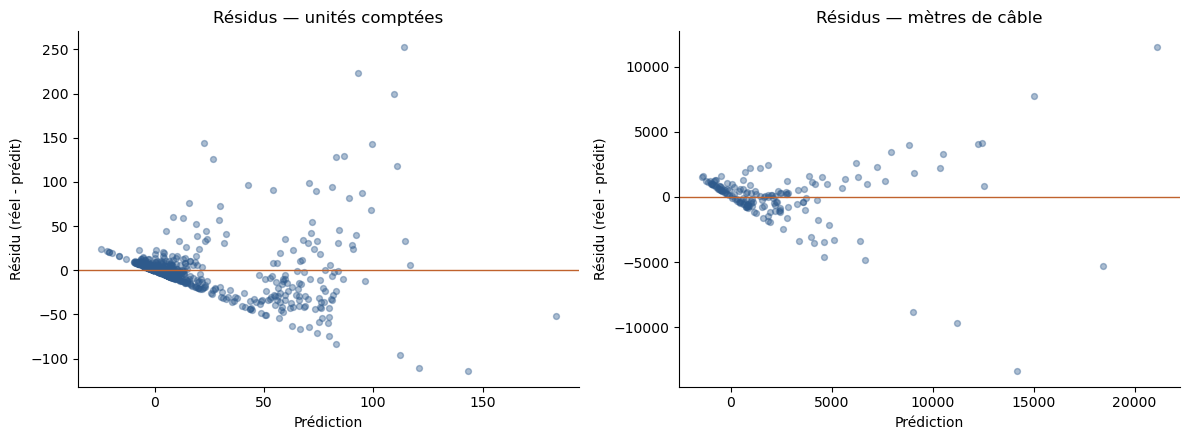

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, unite in zip(axes, ['U', 'm']):
    r = resultats[unite]
    residus = r['y'] - r['pred']
    ax.scatter(r['pred'], residus, alpha=0.4, s=18, color='#2E5A8C')
    ax.axhline(0, color='#C0622D', linewidth=1)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Résidu (réel - prédit)')
    ax.set_title(f"Résidus — {r['label']}")
plt.tight_layout()
plt.show()

**Constat :** les deux graphiques montrent une **hétéroscédasticité classique** — la dispersion des résidus augmente avec la valeur prédite (forme d'entonnoir). Le modèle linéaire est donc relativement fiable sur les petites/moyennes quantités restantes, mais nettement moins précis sur les plus grosses commandes. C'est un argument concret, déjà anticipé dans le plan de mise en œuvre, pour tester un Gradient Boosting Regressor au Jour 3 — les modèles à base d'arbres gèrent nativement ce type de non-linéarité et d'hétéroscédasticité mieux qu'une régression linéaire.

## 5. Sauvegarde des pipelines

Chaque modèle est encapsulé dans un unique `Pipeline` scikit-learn (prétraitement + régression), conformément à la leçon déjà tirée du projet précédent (incident `RobustScaler`) — jamais de prétraitement appliqué séparément du modèle.

In [8]:
import os
os.makedirs('../models', exist_ok=True)

for unite in ['U', 'm']:
    sub = df[df['Unite'] == unite].reset_index(drop=True)
    X_sub = sub[cat_features + num_features]
    y_sub = sub['Quantite_Restante']

    pipe_final = build_pipe(Ridge(alpha=1.0, random_state=42))
    pipe_final.fit(X_sub, y_sub)

    chemin = f'../models/model_A_ressources_{unite}.pkl'
    with open(chemin, 'wb') as f:
        pickle.dump(pipe_final, f)
    print(f"Sauvegardé : {chemin}")

Sauvegardé : ../models/model_A_ressources_U.pkl
Sauvegardé : ../models/model_A_ressources_m.pkl


## 6. Bilan de la sous-étape 2c

| Point vérifié | Résultat |
|---|---|
| Modèle unique mélangeant les unités | Trompeur en apparence (R²=0,77 global), catastrophique sur le sous-groupe « U » — évité |
| Modèles stratifiés par unité | Mètres : MAE≈1 376 m, R²=0,71 · Unités : MAE≈13, R²=0,47 |
| Comparaison au baseline naïf | Gain net dans les deux cas |
| Résidus | Hétéroscédasticité — argument pour tester Gradient Boosting au Jour 3 |
| Fuite de données | Évitée explicitement (`Avancement_Global_Localite_pct` exclu) |
| Encapsulation Pipeline | 2 pipelines sauvegardés (`models/model_A_ressources_{U,m}.pkl`) |

**Prochaine étape (à valider) :** 2d — baseline tendance simple pour le Modèle B (avancement département × semaine).